In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 53)


In [3]:
# TARGET (MORTE)
# =============================

df["target_grave"] = (
    (df["mortos"] > 0) | (df["feridos_graves"] > 0)
).astype(int)

print(df["target_grave"].value_counts(normalize=True))

target_grave
0    0.825025
1    0.174975
Name: proportion, dtype: float64


In [4]:
# KM
df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

# Latitude / Longitude
df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Idade veículo
df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

In [5]:
coords = df[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=100, random_state=42).fit(coords)
df['cluster_localizacao'] = kmeans.predict(df[['latitude', 'longitude']])

In [6]:
df['veiculo_velho'] = (df['idade_veiculo'] > 15).astype(int)
# No LightGBM, isso pode virar uma nova categoria ou feature combinada

In [7]:
df["km_bin"] = (df["km"] // 5) * 5

In [8]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    #'horario',
    "mes",
    "dia_semana",
    'dia_mes',
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    #"idade",
    #'sexo',
    "idade_veiculo",
    #'cluster_localizacao',
    'latitude', 
    'longitude',
    'regional', 
    #'marca',
    'Fabricante',
    #'Modelo'
]

# features = [
#     "hora",
#     "mes",
#     "dia_semana",
#     "tipo_acidente",
#     "fase_dia",
#     "condicao_metereologica",
#     "tipo_pista",
#     "tracado_via",
#     "uso_solo",
#     "tipo_veiculo",
#     "idade",
#     "idade_veiculo",
#     "Fabricante",
#     "Modelo"
# ]


df = df.dropna(subset=["target_grave"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")

categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

C:\Users\fause\AppData\Local\Temp\ipykernel_26188\498528044.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [9]:
X = df[features]
y = df["target_grave"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 importante (balanceamento)
)

In [10]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

# modelo = lgb.LGBMRegressor(
#     n_estimators=800,          # mais árvores
#     learning_rate=0.03,        # aprendizado mais suave
#     num_leaves=128,            # mais capacidade
#     max_depth=-1,              # sem limite explícito
#     min_child_samples=40,      # evita overfitting
#     subsample=0.8,             # bagging
#     colsample_bytree=0.8,      # feature sampling
#     reg_alpha=0.5,             # regularização L1
#     reg_lambda=0.5,            # regularização L2
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512
# )

# modelo.fit(X_train, y_train)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)
modelo = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    #scale_pos_weight=scale_pos_weight,
    scale_pos_weight=2.5,
    reg_alpha=0.3,
    reg_lambda=0.3,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

4.715100539730646
[LightGBM] [Info] Number of positive: 234932, number of negative: 1107728
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044996 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1504
[LightGBM] [Info] Number of data points in the train set: 1342660, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174975 -> initscore=-1.550770
[LightGBM] [Info] Start training from score -1.550770


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [11]:
pred = modelo.predict(X_test)
proba = modelo.predict_proba(X_test)[:,1]

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("ROC AUC:", roc_auc_score(y_test, proba))


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.90    276933
           1       0.53      0.61      0.56     58733

    accuracy                           0.84    335666
   macro avg       0.72      0.75      0.73    335666
weighted avg       0.85      0.84      0.84    335666

ROC AUC: 0.8610699347780926


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definir a estratégia de validação (5 ou 10 folds é o padrão)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir as métricas que queremos monitorar
# 'f1_weighted' é bom para classes desbalanceadas, 
# 'roc_auc' mede a capacidade de separação
metricas = ['precision', 'recall', 'f1', 'roc_auc']

print(f"Iniciando Cross-Validation com {skf.get_n_splits()} folds...\n")

# 3. Executar o Cross-Validation
# Nota: Passamos o X e y completos (ou X_train e y_train)
cv_results = cross_validate(
    modelo, X, y, 
    cv=skf, 
    scoring=metricas, 
    n_jobs=-1, 
    return_train_score=False
)

# 4. Exibir os resultados médios
print("-" * 30)
print("RESULTADOS MÉDIOS (CV):")
print(f"ROC AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f}")
print("-" * 30)

Iniciando Cross-Validation com 5 folds...

------------------------------
RESULTADOS MÉDIOS (CV):
ROC AUC:   0.8613 (+/- 0.0006)
Recall:    0.6059
Precision: 0.5269
F1-Score:  0.5636
------------------------------


In [13]:
import pandas as pd

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

          feature  importance
11    tracado_via        6612
18     Fabricante        4622
2          km_bin        2736
14  idade_veiculo        2275
17       regional        2205
0              uf        2022
16      longitude        2011
6         dia_mes        1926
3            hora        1909
15       latitude        1886
5      dia_semana        1781
13   tipo_veiculo        1636
4             mes        1407
7   tipo_acidente        1340
1              br        1252


c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


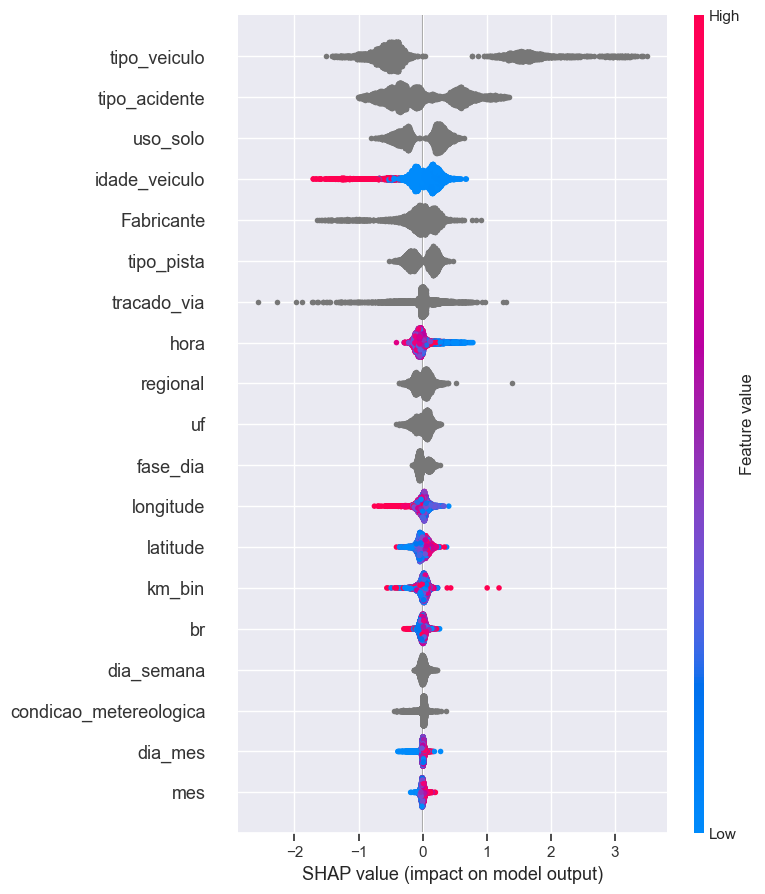

In [14]:
import shap

X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [15]:
print("Shape inicial:", df.shape)

Shape inicial: (1678326, 58)


          feature  importance
11    tracado_via        6612
18     Fabricante        4622
2          km_bin        2736
14  idade_veiculo        2275
17       regional        2205
0              uf        2022
16      longitude        2011
6         dia_mes        1926
3            hora        1909
15       latitude        1886
5      dia_semana        1781
13   tipo_veiculo        1636
4             mes        1407
7   tipo_acidente        1340
1              br        1252


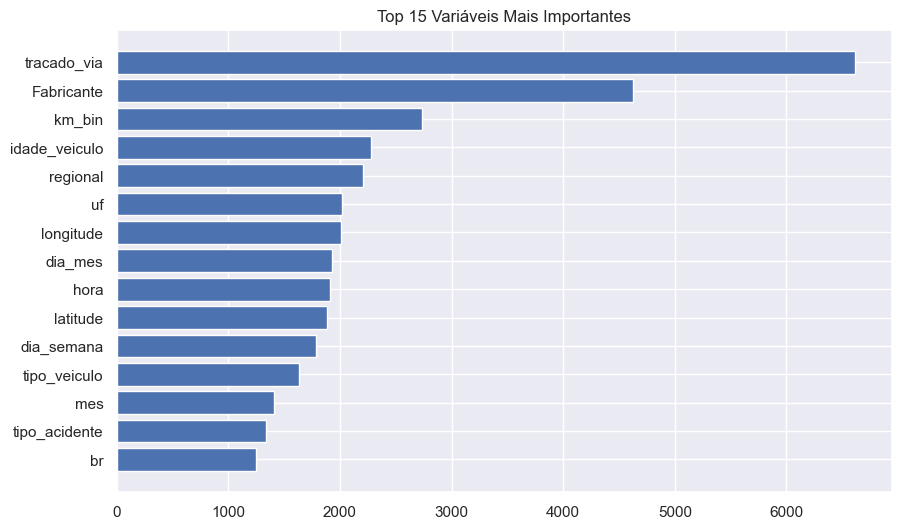

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

plt.figure(figsize=(10,6))
plt.barh(importancia["feature"][:15][::-1], importancia["importance"][:15][::-1])
plt.title("Top 15 Variáveis Mais Importantes")
plt.show()

In [17]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    features = [
        ("hora", None),
        ("mes", None),  # no seu caso já é numérico
        ("dia_semana", ["dia_semana"]),
        ("idade_veiculo", None),
        ("tipo_pista", ["tipo_pista"]),
        ("fase_dia", ["fase_dia"]),
        ("condicao_metereologica", ["condicao_metereologica"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            grid_resolution=50 if feature == "idade_veiculo" else 100,
            kind="average",
            response_method="predict_proba"  # 🔥 IMPORTANTE
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        plt.ylabel("Probabilidade de Acidente Grave")  # 🔥 importante

        if feature == "idade_veiculo":
            plt.xlim(0, 35)

        plt.show()

    # 🔥 interação por clima
    top_climas = X["condicao_metereologica"].value_counts().head(4).index

    for clima in top_climas:
        subset = X[X["condicao_metereologica"] == clima]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"],
            response_method="predict_proba"  # 🔥 aqui também
        )

        plt.title(f"{nome_modelo} - Risco por hora ({clima})")
        plt.ylabel("Probabilidade de Acidente Grave")
        plt.show()

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


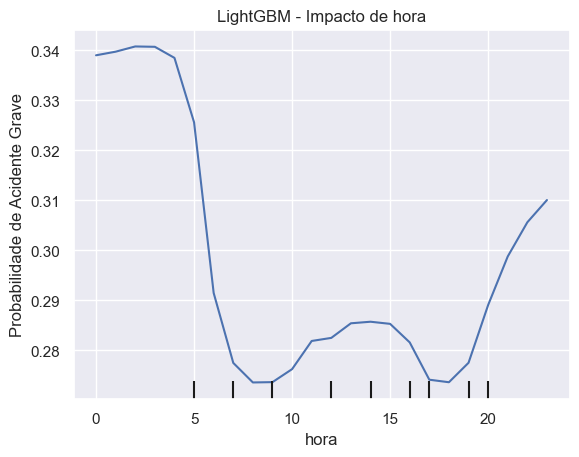

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


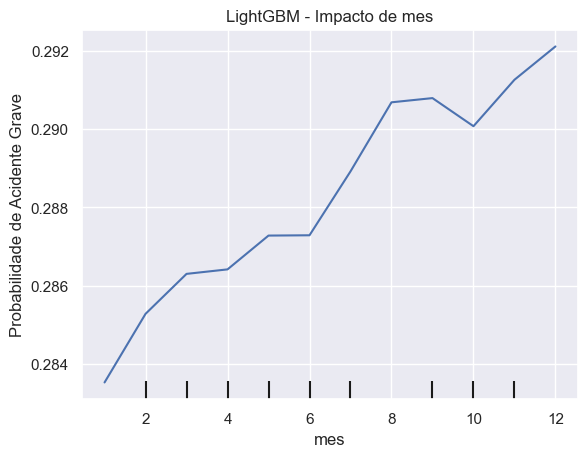

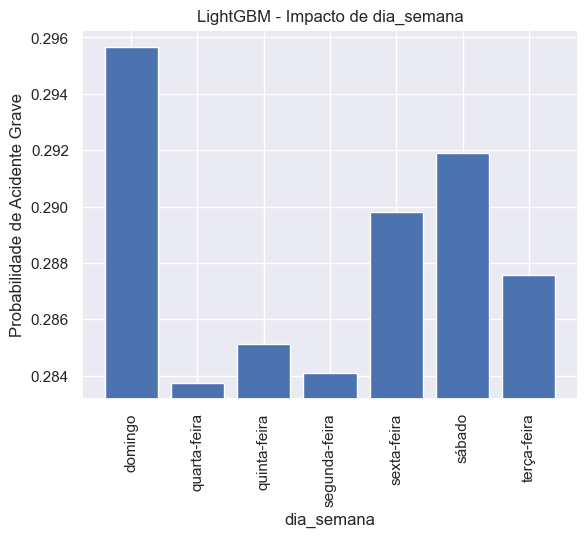

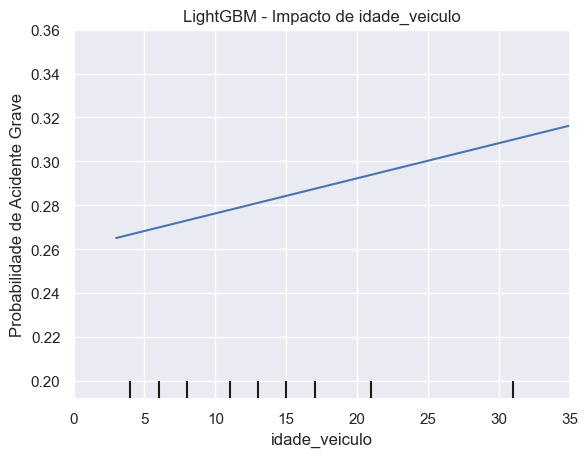

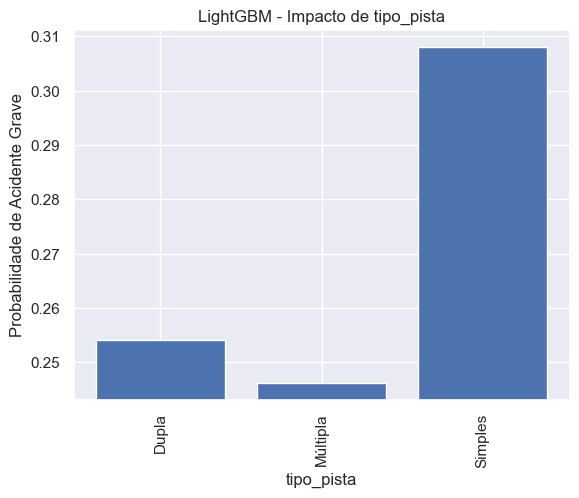

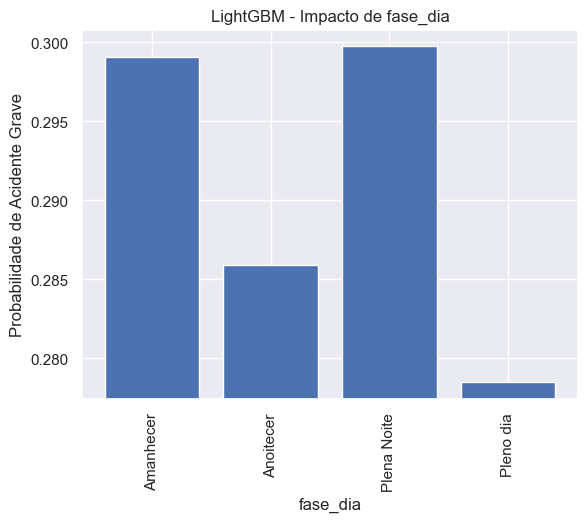

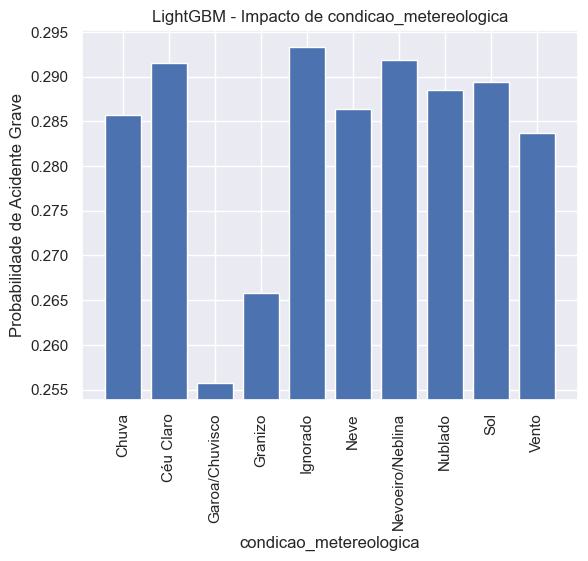

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


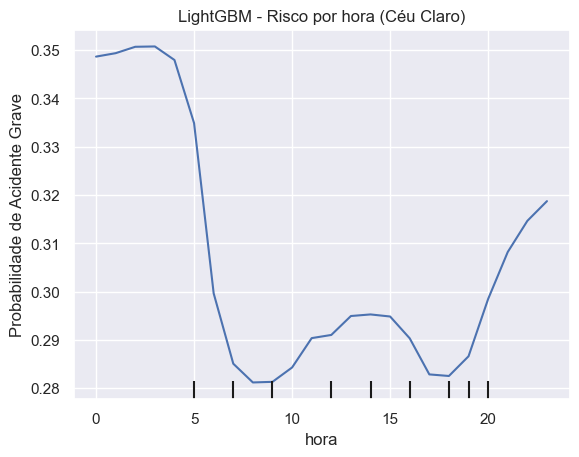

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


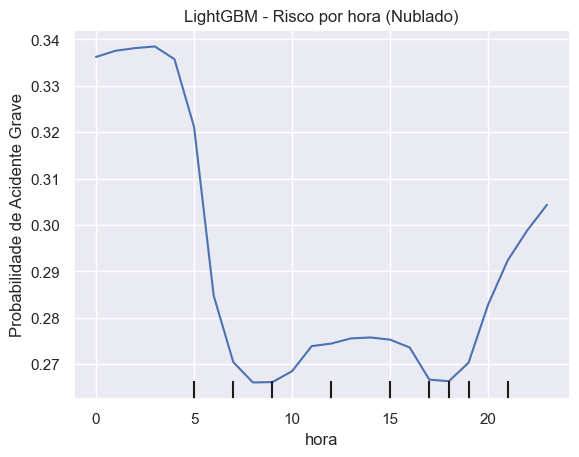

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


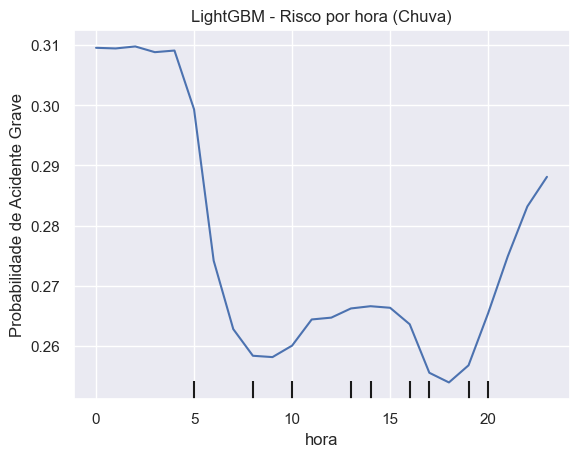

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


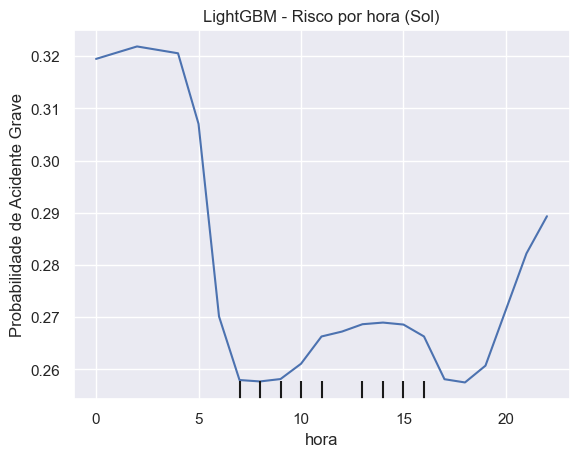

In [18]:
rodar_pdp(modelo, X_test, nome_modelo="LightGBM")

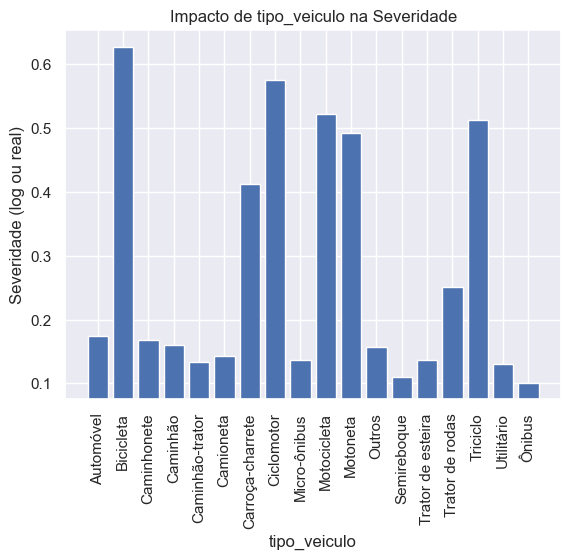

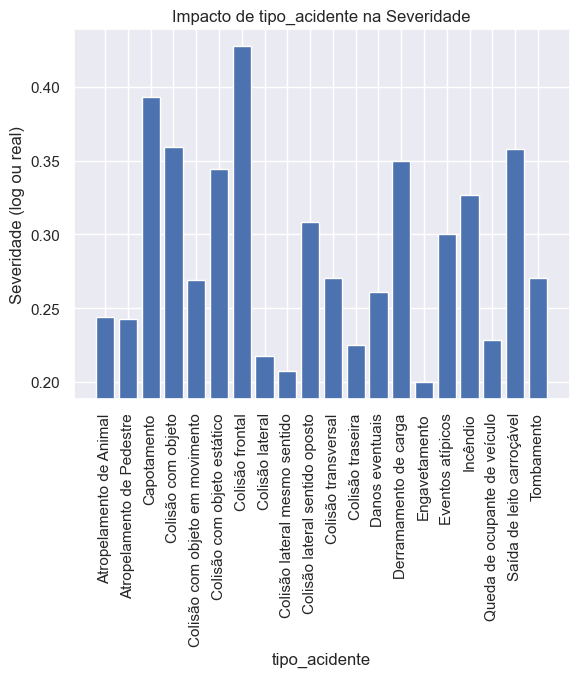

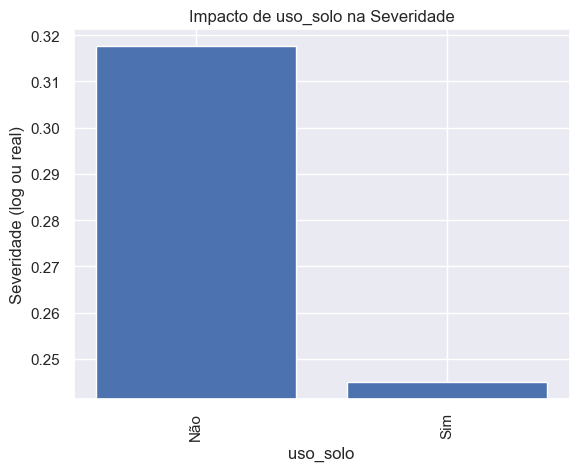

In [19]:
features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )

    plt.title(f"Impacto de {feature} na Severidade")
    plt.ylabel("Severidade (log ou real)")
    plt.show()